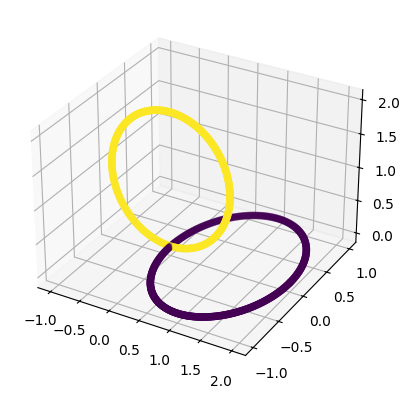

In [3]:
import torch
from ebm.util.config import Config
from ebm.networks import get_network
from ebm.networks import DeepHopfieldNetwork
from ebm.estimators.gradient_estimators import EquiPropEstimator
from ebm.estimators.optimizer import SGDOptimizer
from ebm.estimators.cost import SquaredError
from ebm.runner import NetworkRunner

# Create a toy dataset of 2 interlocking rings in 3D and with 1000 points and labels for each point
# Create a toy dataset of interlocking rings perpendicular to each other in 3D
num_points = 500
theta = torch.linspace(0, 2 * torch.pi, num_points)

# First ring in the XY plane, centered at (1, 0, 0)
x1 = 1 + torch.cos(theta)
y1 = torch.sin(theta)
z1 = torch.zeros(num_points)

# Second ring in the XZ plane, centered at (0, 0, 1)
x2 = torch.cos(theta)
y2 = torch.zeros(num_points)
z2 = 1 + torch.sin(theta)

# Combine the rings
X1 = torch.stack([x1, y1, z1], dim=1)
X2 = torch.stack([x2, y2, z2], dim=1)
X = torch.cat([X1, X2], dim=0)

# Labels for the rings
Y1 = torch.zeros(num_points, dtype=torch.int32)
Y2 = torch.ones(num_points, dtype=torch.int32)
Y = torch.cat([Y1, Y2], dim=0)
# Plot the dataset
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.scatter(X[:, 0], X[:, 1], X[:, 2], c=Y, cmap='viridis')
plt.show()


In [4]:
# Create a dataloader for the dataset
dataset = torch.utils.data.TensorDataset(X, Y)
dataloader = torch.utils.data.DataLoader(dataset, batch_size=32, shuffle=True)
# Split the dataset into a training and test set
train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size
train_dataset, test_dataset = torch.utils.data.random_split(dataset, [train_size, test_size])
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=32, shuffle=True)

In [6]:
dataset = 'TwoMoons'
config = Config()
#network = get_network(config)
layers = [2,128,2] #config.layers
network = DeepHopfieldNetwork(layers,config)
cost_function = SquaredError(network)
optimizer = SGDOptimizer(network,cost_function)
estimator = EquiPropEstimator(network, cost_function)
runner = NetworkRunner(network,estimator,optimizer, train_loader, test_loader)
runner.train(num_epochs=100)
runner.eval(custom=False)

TypeError: NetworkRunner.__init__() missing 2 required positional arguments: 'eval_dataloader' and 'config'